In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
from scipy.integrate import quad

from crc_scripts.io.gizmo import *
from crc_scripts import config
from crc_scripts.observations import dust_obs as obs
from crc_scripts.observations.obs_data import Observational_Data
import crc_scripts.utils.math_utils as math_utils
import crc_scripts.utils.snap_utils as snap_utils
import crc_scripts.utils.data_calc_utils as calc
import crc_scripts.utils.grain_size.grain_size_utils as grain_size_utils
from crc_scripts.utils.SKIRT.SKIRT_utils import create_SKIRT_particle_files
import crc_scripts.analytical_models.grain_size_evo as gse
from crc_scripts.figure import Figure,Projection
from crc_scripts.analysis.data_reduction import MultiSnapDataIO
import crc_scripts.utils.plot_utils as plt_set
import matplotlib.lines as mlines

import crc_scripts.analytical_models.grain_size_evo as gse_models

# First setup directory for all the plots
plot_dir = os.path.join(os.environ['SLATE'],'dust_size_evo/')
os.makedirs(plot_dir, exist_ok=True)

# Appendix Plots

## Dust size distribution change for various processes
Create some useful plots showing how an MRN size distribtuion will change due to each dust process along with general timescales for each

#### Coagulation

In [ ]:
foutname = plot_dir+'analytical_coagulation_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'MC'
dt = 0.01
subcycle_constraint = 'both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, subcycle_constraints=subcycle_constraint, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Shattering
Note the increase at the smallest grain size bin is due to rebinning shattered fragments beyond the minimum grain size back to the smallest bin.

In [ ]:
foutname = plot_dir+'analytical_shattering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32

fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.2
dt = 0.02
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


In [ ]:
foutname = plot_dir+'analytical_shattering_pred_lognorm.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.lognorm_dnda
def init_dmda(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax, args=(0.1,0.6))[0]
init_dm_norm = 1/quad(init_dmda,amin,amax, args=(0.1,0.6))[0]
bin_nums=8


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH


fig.plot_line_data(0,a_bins,init_dnda(a_bins,a_norm=0.1)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins,a_norm=0.1)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(new_dnda(a_bins)[new_dnda(a_bins)>0]),np.power(10,0.5)*np.max(new_dnda(a_bins)[new_dnda(a_bins)>0])])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(new_dmdloga(a_bins)[new_dmdloga(a_bins)>0]),np.power(10,0.5)*np.max(new_dmdloga(a_bins)[new_dmda(a_bins)>0])])


species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.5
dt = 0.005
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Accretion

In [ ]:
foutname = plot_dir+'analytical_accretion_pred_enh.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'CNM'
dt = 0.005
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmda(a_bins)*a_bins, color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


Testing different subcycling prescriptions.
Decided on using the minimum bin.

In [ ]:
foutname = 'analytical_acretion_pred_subcycling_comparisons.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

spec = 'silicates'
ISM_phase = 'CNM'
dt = 0.001
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints=['none','size','min_bin']

for i,subcycle in enumerate(subcycle_constraints):
    print(subcycle)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Thermal Sputtering

In [ ]:
foutname = plot_dir+'analytical_sputtering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'HIM'
dt = 0.1
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Simple visualizations for dust processes diagram

This are parameters every diagram uses.

In [ ]:
amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
# Normalize by the total mass
def init_dmdloga_normed(a):
    return init_dmdloga(a)*init_dm_norm

a_vals = np.logspace(np.log10(amin),np.log10(amax),num=100)
dmdloga_limits = [np.power(10,-0.5)*np.min(init_dmdloga_normed(a_vals)),np.power(10,0.5)*np.max(init_dmdloga_normed(a_vals))]


colors = ["xkcd:dark royal blue","xkcd:forest green","xkcd:indian red",]
colors = ["xkcd:red","xkcd:green","xkcd:blue",]
linestyles = config.LINE_STYLES[:5]
linestyles = ['-','--','-.',':']
linewidth = 3.75*config.BASE_LINEWIDTH

species = ['silicates','carbonaceous','iron']
init_depl = 0.3 # initial depletion of key element for dust species


##### Accretion

In [ ]:
foutname = plot_dir+'grain_size_accretion_diagram.pdf'
ISM_phase = 'CNM'
dt = 0.01
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### Sputtering

In [ ]:
foutname = plot_dir+'grain_size_sputtering_diagram.pdf'

ISM_phase = 'HIM'
dt = 1
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)
    

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %1.0f $ Gyr'%(dt)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Shattering

In [ ]:
foutname = plot_dir+'grain_size_shattering_diagram.pdf'

ISM_phase = 'WIM'
dt = 0.05
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Coagulation

In [ ]:
foutname = plot_dir+'grain_size_coagulation_diagram.pdf'

ISM_phase = 'MC'
dt = 0.01
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### SNe Shocks

In [ ]:

foutname = plot_dir+'grain_size_SNe_shock_diagram.pdf'

# Set limits for size distribution

bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

dt = 0.0001
approx='shat_sput_shat'

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i, spec in enumerate(species):
    f_SNe,dnda_SNe,dmda_SNe = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', species=spec)
    # Renorm dmda to 1/total_mass/fSNe
    total_mass = quad(dmda_SNe,amin,amax)[0]
    fig.plot_line_data(0,a_bins,dmda_SNe(a_bins)*a_bins/(total_mass), color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t \sim %1.1f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

## Thermal Erosion Rate Comparison

In [ ]:

Tsput = 2E6; 
T_limits = [3E4,5E7]
T = np.logspace(np.log10(T_limits[0]), np.log10(T_limits[1]), 100)
Y_Tsai = 3.2E-18 / (np.power((Tsput/T),2.5) + 1) * config.cm_to_um / config.sec_to_Gyr;

x = np.log10(T)
Y_carb = np.power(10,-226.85176513236104 + 133.44188274964907*x - 32.57239140566398*np.power(x,2) + 4.005662246063896*np.power(x,3) - 0.247470977981441*np.power(x,4) + 0.0061211887939359045*np.power(x,5)) / 1E-9
Y_sil = np.power(10,-226.94973608304852 + 127.94268281713853*x - 29.91964844780188*np.power(x,2) + 3.5354022742488267*np.power(x,3) - 0.21055294512995676*np.power(x,4) + 0.0050362487746130735*np.power(x,5)) / 1E-9
Y_Fe = np.power(10,-156.87812803401695 + 82.10982096578688*x - 18.237504267725893*np.power(x,2) + 2.0691984369187524*np.power(x,3) - 0.11933080830511887*np.power(x,4) + 0.00277875641831501*np.power(x,5)) / 1E-9
N=5
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

y_label = r'$Y_{\rm dust}\;(\mu m \; {\rm Gyr}^{-1} \;{\rm cm^{3}})$'
fig = Figure(1)
fig.set_axis(0, 'T', 'erosion_rate', x_lim=T_limits, x_log=True, y_label=y_label, y_lim=[np.max(Y_sil)*1E-3, 2*np.max(Y_sil)], y_log=True)

fig.plot_line_data(0, T, Y_Tsai, color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH, label='Tsai+95')
i=0
fig.plot_line_data(0, T, Y_sil, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='silicates')
i=1
fig.plot_line_data(0, T, Y_carb, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='carbon')
i=2
fig.plot_line_data(0, T, Y_Fe, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='iron')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(plot_dir+'dust_erosion_rate.pdf')

## Sub-Resolved Gas Clumping

In [ ]:
from scipy.special import erfc,erf

foutname = 'clumping_factor.pdf'

M_limits = [0.2,100]
C_limits = [0.1,100]
nmaxs = [1E3,1E4,1E3,1E4]
ns=[1E0,1E0,1E2,1E2]


M = np.logspace(np.log10(M_limits[0]),np.log10(M_limits[1]),100)
b = 0.5 # ratio of solenoidal to compressive turbulence
sigma = np.sqrt(np.log(1+b*b*M*M))

N = len(nmaxs)

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

x_label = r'$\mathcal{M}$'
y_label = r'$C_{2,k}$'
fig = Figure(1)
fig.set_axis(0, 'M', 'clumping_factor', x_lim=M_limits, x_log=True, x_label=x_label, y_label=y_label, y_lim=C_limits, y_log=True)



for i in range(N):
    nmax=nmaxs[i]
    n=ns[i]
    clumping_factor = np.exp(sigma*sigma)/2 * erfc((3/2*sigma*sigma-np.log(nmax/n)) / (np.sqrt(2)*sigma))
    label = r'$\bar{n}=10^{%i}\,{\rm cm^{-3}}$; $ n_{\rm max}=10^{%i}\,{\rm cm^{-3}}$'%(np.log10(n),np.log10(nmax))
    fig.plot_line_data(0,M,clumping_factor,label=label,linestyle=linestyles[i],color=colors[i], linewidth=linewidth)
    
    if i == N-1:
        T_clumping_factor = 1/(np.exp(sigma*sigma)/2 * (1 + erf((3/2*sigma*sigma + np.log(nmax/n)) / (np.sqrt(2)*sigma))))
        label = r'$C_T$'
        fig.plot_line_data(0,M,T_clumping_factor,label=label,linestyle='-',color='xkcd:grey', linewidth=1.7*linewidth,zorder=-3)

fig.set_all_legends(rescale_font=0.7,max_cols=1)

fig.save(plot_dir+foutname)

## Turbulence Driven Grain Velocity

In [ ]:

foutname = plot_dir+'Lebreuilly23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, ISM_phase='CNM', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,ISM_phase='MC', scheme='Lebreuilly23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'Li21_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=1E0*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)
    
for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='Li21')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:

foutname = plot_dir+'HC23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=0.5*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
dust_atomic_weight = spec_props['dust_atomic_weight']
key_mass = spec_props['key_mass']
key_abundance = spec_props['key_abundance']
key_num_atoms = spec_props['key_num_atoms'] 
P1 = spec_props['P1']
v_shat = spec_props['v_shat']/1E5 # km/s
poisson = spec_props['poisson']
youngs = spec_props['youngs']
gamma = spec_props['gamma']
rho_c = spec_props['rho_c']


# Plot coagulation velocities
for i,a2 in enumerate(a2s):
    v_coag = gse.v_coagulation(a2,a2,rho_c, poisson, youngs, gamma)/1E5 # km/s
    x_values = a1s * config.cm_to_um  # Use the x values from a1s
    y_values = np.full(len(a1s), v_coag)  # Create constant y values
    fig.plot_line_data(0,x_values,y_values, color=colors[i], linewidth=0.25*linewidth, linestyle='dashed')


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'CNM', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

In [ ]:
v1 = 1
v2 = 1

N=10000


xlim= [0.1,100]
ylim = [0,1]

colors = config.LINE_COLORS[:2]
linestyles = config.LINE_STYLES[:2]
linewidth = 2*config.BASE_LINEWIDTH

labels = ['Li+21','Hirashita+09']

y_label = 'CDF'
x_label = r'$v_{\rm rel}$'
fig = Figure(1)
fig.set_axis(0, 'vrel', 'prob', x_lim=xlim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=False)

# Determine relative velocities by taking the difference of x, y, and z components
vrel = np.zeros(N)
for i in range(3):
    v1i=np.random.normal(0,v1*v1/3,1000)
    v2i=np.random.normal(0,v2*v2/3,1000)
    vrel = np.power(v1i-v2i,2)
vrel=np.sqrt(vrel)

#fig.plot_1Dhistogram(0,vrel,bin_log=True)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[0])


impact_angle = np.random.uniform(-1,1,N)
vrel = np.sqrt(v1*v1 + v2*v2 - 2*v1*v2*impact_angle)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[1])

fig.set_all_legends()



## Coagulation Velocity

In [ ]:
foutname=plot_dir+'coagulation_velocity.pdf'

alim= [0.001,1]
a_vals = np.logspace(np.log10(alim[0]),np.log10(alim[1]),100)*1E-4
ylim = [5E-4,1E1]

colors = config.LINE_COLORS[:3]
linestyles = config.LINE_STYLES[:3]
linewidth = config.LINE_WIDTHS[[0,3]]


y_label = r'$v_{\rm coag}$ (km/s)'
x_label = r'$a_j$ ($\mu m$)'

fig = Figure(1)
fig.set_axis(0, 'vcoag', 'aj', x_lim=alim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=True)

species = ['silicates','carbonaceous','iron']
# The grain sizes for the target grain
aks = np.array([0.1,0.001])*1E-4 # cm

for i in range(len(species)):
    
    # Get species properties
    spec_props = gse.dust_species_properties(species[i])
    dust_atomic_weight = spec_props['dust_atomic_weight']
    key_mass = spec_props['key_mass']
    key_abundance = spec_props['key_abundance']
    key_num_atoms = spec_props['key_num_atoms'] 
    P1 = spec_props['P1']
    v_shat = spec_props['v_shat']/1E5 # km/s
    poisson = spec_props['poisson']
    youngs = spec_props['youngs']
    gamma = spec_props['gamma']
    rho_c = spec_props['rho_c']

    for j, ak in enumerate(aks):
        v_coag = gse.v_coagulation(ak,a_vals,rho_c, poisson, youngs, gamma)/1E5 # km/s

        fig.plot_line_data(0,a_vals/1E-4,v_coag,label=species[i],linestyle=linestyles[i],color=colors[i], linewidth=linewidth[j])

        if j==0:
            if i == len(species)-1: vshat_label=r'$v_{\rm shat}$'
            else: vshat_label=None
            vshat_line = mlines.Line2D(alim,[v_shat,v_shat], c='xkcd:grey',label=vshat_label,linewidth=config.BASE_LINEWIDTH,linestyle=linestyles[i],zorder=-3)
            fig.add_artist(0,vshat_line)
        
        if i == len(species)-1:
            new_label=r'$a_k=%g \, \mu m$'%(ak*1E4)
            fig.plot_line_data(0,[config.EPSILON],[config.EPSILON],label=new_label,linestyle='-',color='xkcd:black', linewidth=linewidth[j])



fig.set_all_legends(rescale_font=1/1.25,ncols=2,loc='lower left')

fig.save(foutname)

# Analytical Testing

## SNe Dust Destruction

### Sputtering and shattering efficiency functions

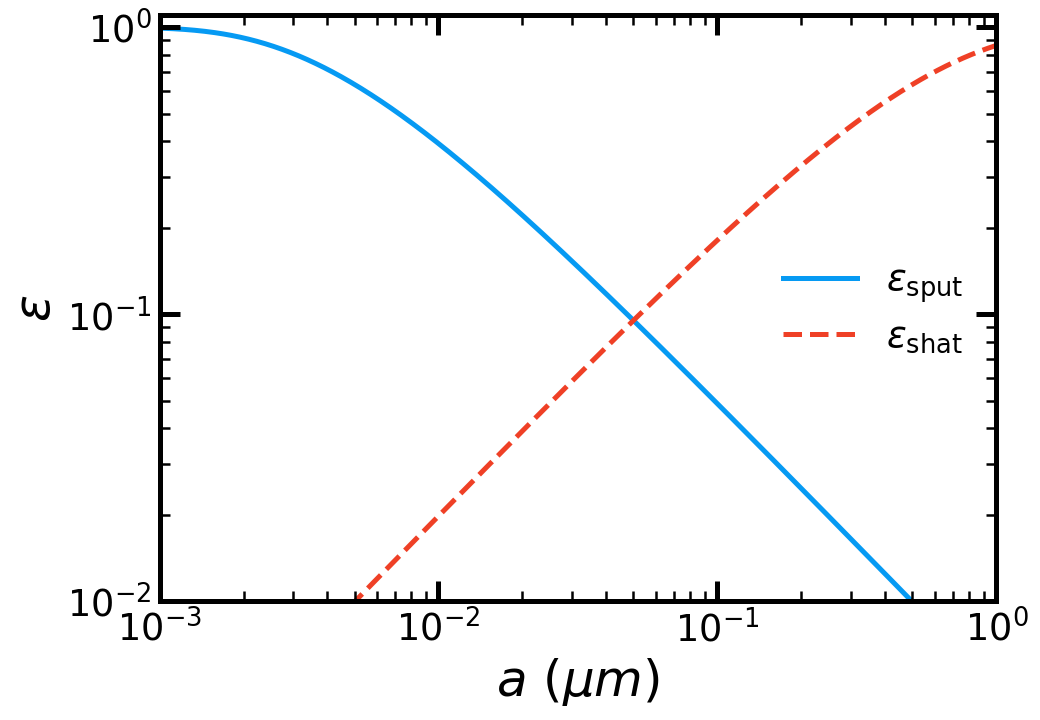

In [110]:
N = 5

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH


a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.1;
delta_shat = 0.1;
a_limit = [1E-3,1E0]
a = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),500)


y_label = r'$ \epsilon $'
x_label = r'$a$ ($\mu m$)'
eff_limits = [1E-2,1.1]
fig = Figure(1)
fig.set_axis(0, 'a', 'eff', x_lim=a_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=eff_limits, y_log=True)


def eff_sput(a):
        return (1 - np.exp(-(delta_sput / (a/a_sput))))
def eff_shat(a):
        return (1 - np.exp(-(delta_shat * (a/a_shat))))

i=0
fig.plot_line_data(0,a,eff_sput(a),label=r'$\epsilon_{\rm sput}$',color=colors[i], linestyle=linestyles[i])
i=1
fig.plot_line_data(0,a,eff_shat(a),label=r'$\epsilon_{\rm shat}$',color=colors[i], linestyle=linestyles[i])
fig.set_all_legends()

### Total dust destruction fraction
This tests the shattering+sputtering and shattering+sputting+shattering routines for varying sputtering and shattering efficiencies

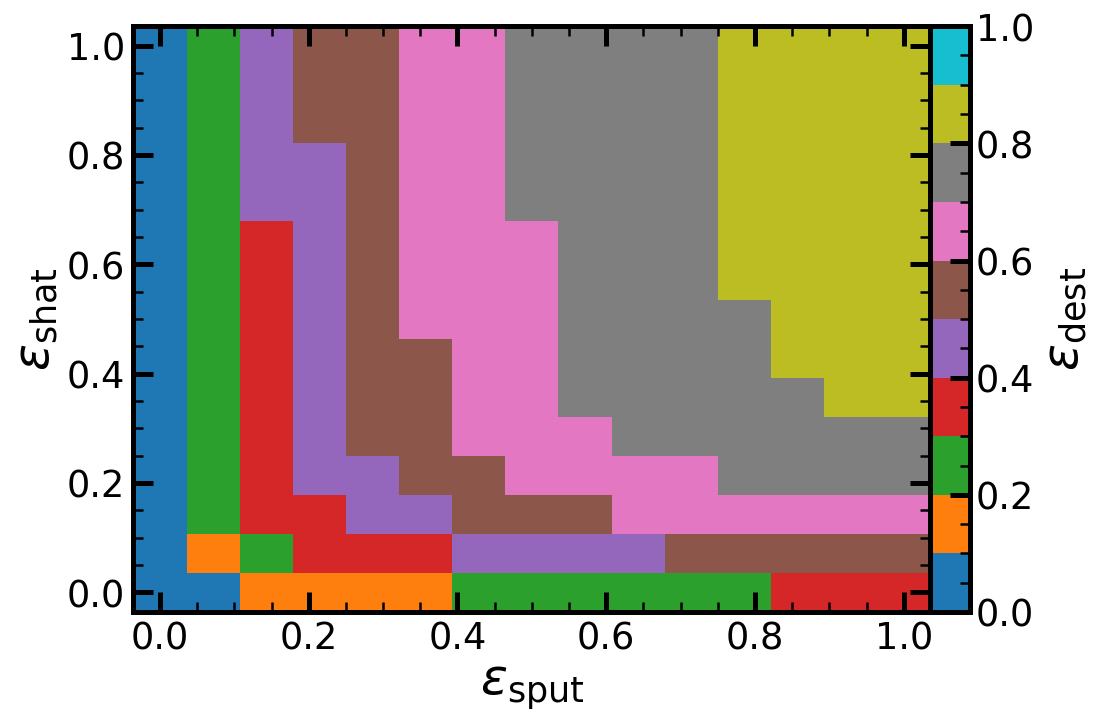

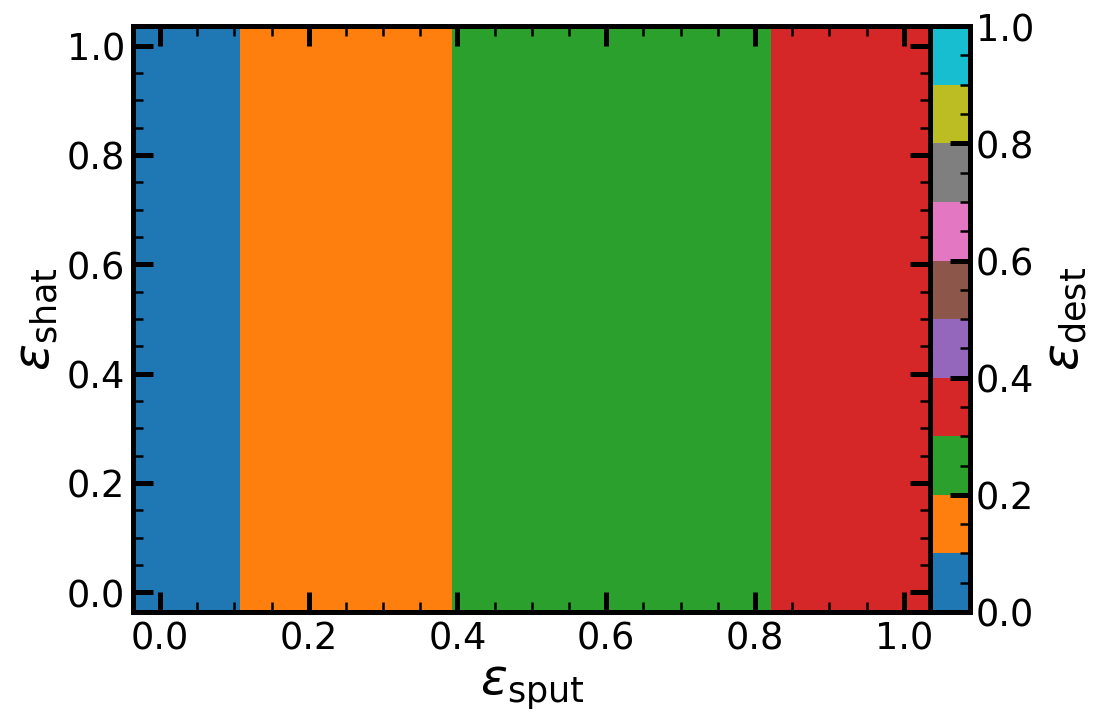

In [2]:
# Set limits for size distribution
amin = 1E-3
amax=1E0
bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

a_sput = 0.05; # microns
a_shat = 0.05;
a_frag_max = a_shat

init_dnda=gse.MRN_dnda

N=15
eff_shats = np.linspace(0,1,N)
eff_sputs = eff_shats
f_dest = np.zeros((N,N))

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)



color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

approx='shat_sput_shat'

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp, delta_shat = eff_sh, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)

approx='sput'

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp,a_sput=a_sput)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)


### Comparing SNe grain size destruction models

0.0
0.0
0.0
0.0
2.2826985946869837e-08
1.6542791412560997e-08
1.7514873686780373e-08
1.1306539004181833e-08
Initial MRN
Sh+Sp+Sh Dest Frac 1: 0.5250927769306091
Sh+Sp+Sh Dest Frac 2: 0.28822857022759474
Sp Only Dest Frac: 0.5633972827586999
Nozawa+06 Dest Frac: 0.5757067902072475


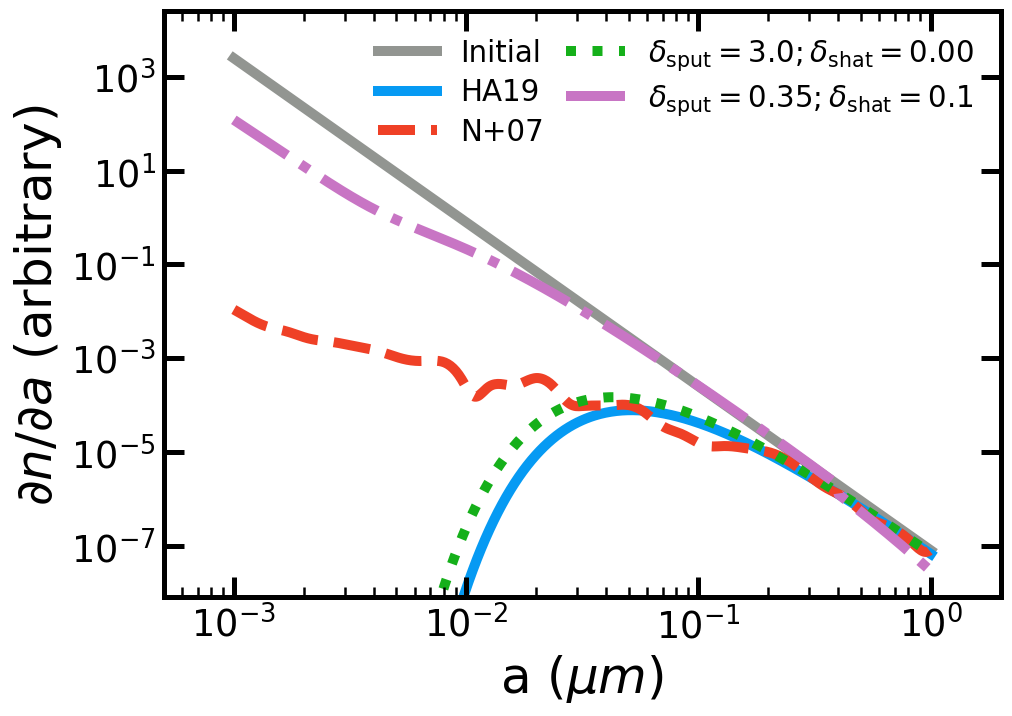

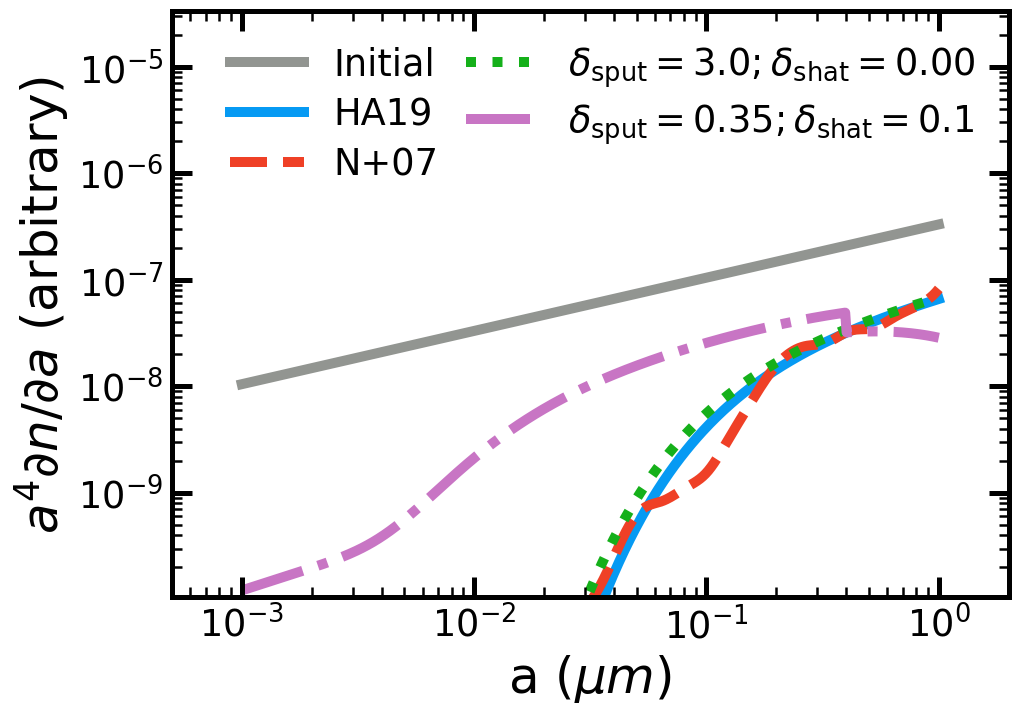

In [9]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.9;
delta_shat = 0.07;


delta_sput = 3;
delta_shat = 0.0;

a_frag_max = a_shat

f_shspsh1,dnda_shspsh1,dmda_shspsh1 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label1 = r'$\delta_{\rm sput}=%0.1f ; \delta_{\rm shat}=%0.2f$'%(delta_sput,delta_shat)

delta_sput = 0.35;
delta_shat = 0.1;


a_shat = 0.2;
delta_sput = 0.35;
delta_shat = 0.1;
a_frag_max = 2*a_shat

f_shspsh2,dnda_shspsh2,dmda_shspsh2 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label2 = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.9, a_sput=0.2)

f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')


print("Initial MRN")
print("Sh+Sp+Sh Dest Frac 1:",f_shspsh1)
print("Sh+Sp+Sh Dest Frac 2:",f_shspsh2)
print("Sp Only Dest Frac:",f_sp)
print("Nozawa+06 Dest Frac:",f_noz)

y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dnda_sp(a_bins),label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_noz(a_bins),label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh1(a_bins),label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh2(a_bins),label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'MRN_dnda_SNe_comparison.pdf')

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)


fig.plot_line_data(0,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dmda_sp(a_bins)*a_bins,label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_noz(a_bins)*a_bins,label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh1(a_bins)*a_bins,label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh2(a_bins)*a_bins,label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends()
fig.save(plot_dir+'MRN_dmda_SNe_comparison.pdf')

In [ ]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm



y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(2)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig.set_axis(1, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
fig.plot_line_data(1,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

species=['silicates','carbonaceous','iron']
for i,spec in enumerate(species):
    f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat',species=spec)

    print("%s dest frac: %f"%(spec,f_shspsh))

    fig.plot_line_data(0,a_bins,dnda_shspsh(a_bins),label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
    fig.plot_line_data(1,a_bins,dmda_shspsh(a_bins)*a_bins,label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)

fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'SNe_dest_species_comparison.pdf')
